# 2- Image Classification with CNN for Malaria Data

Download dataset https://www.kaggle.com/code/kushal1996/detecting-malaria-cnn

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator # veriyi okuyabilmek için

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Görselleri normalize etmek için (0-255 -> 0-1 arası)
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [4]:
# Eğitim verisi (%80)
train_gen = datagen.flow_from_directory(
    "cell_images\cell_images",
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset='training'
)


Found 22048 images belonging to 2 classes.


In [5]:
# Doğrulama verisi (%20)
val_gen = datagen.flow_from_directory(
    "cell_images\cell_images",
    target_size=(128, 128),
    batch_size=16,
    class_mode="binary",
    subset='validation'
)

Found 5510 images belonging to 2 classes.


## CNN Model

In [6]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Dropout,Flatten,Dense,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
model = Sequential()
model.add(Conv2D(16,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.2))

model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.3))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         802,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 826,529 (3.15 MB)

 Trainable params: 826,529 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [10]:
early_stop = EarlyStopping(monitor='val_loss',patience=2)

In [11]:
history = model.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    epochs=20,
    validation_data=val_gen,
    validation_steps=len(train_gen),
    callbacks=[early_stop]
)

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.7631 - loss: 0.4942 - val_accuracy: 0.9318 - val_loss: 0.1961
Epoch 2/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 51s 74ms/step - accuracy: 0.9365 - loss: 0.2131 - val_accuracy: 0.9361 - val_loss: 0.1941
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 50s 73ms/step - accuracy: 0.9447 - loss: 0.1844 - val_accuracy: 0.9363 - val_loss: 0.1818
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step - accuracy: 0.9508 - loss: 0.1685 - val_accuracy: 0.9428 - val_loss: 0.1834
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 50s 73ms/step - accuracy: 0.9556 - loss: 0.1536 - val_accuracy: 0.9405 - val_loss: 0.1847


## Plots

In [12]:
import matplotlib.pyplot as plt

In [13]:
def plotLearningCurve(history,epochs):
  epochRange = range(1,epochs+1)
  plt.plot(epochRange,history.history['accuracy'])
  plt.plot(epochRange,history.history['val_accuracy'])
  plt.title('Model Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend(['Train','Validation'],loc='upper left')
  plt.show()

  plt.plot(epochRange,history.history['loss'])
  plt.plot(epochRange,history.history['val_loss'])
  plt.title('Model Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend(['Train','Validation'],loc='upper left')
  plt.show()

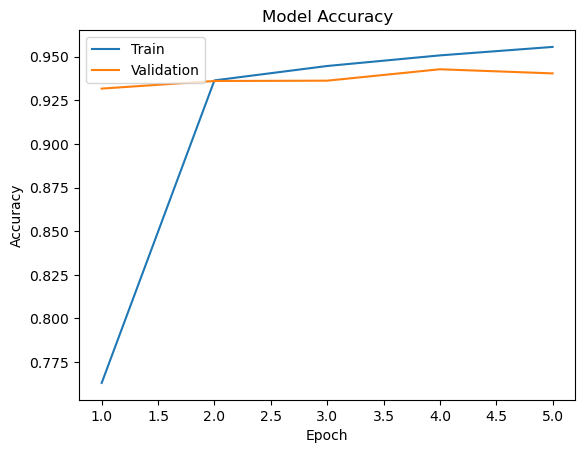

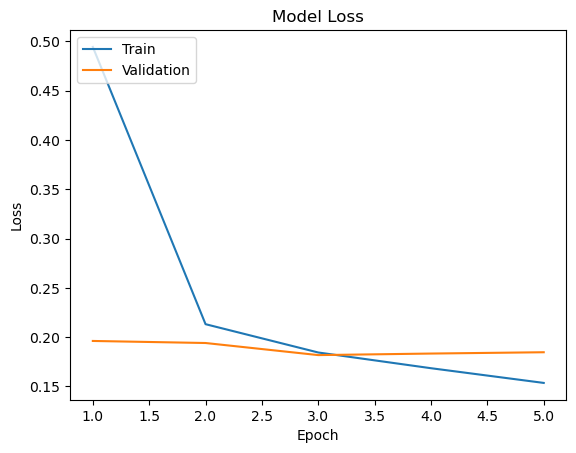

In [14]:
plotLearningCurve(history,5)

## VGG16 Model

In [15]:
train_gen = datagen.flow_from_directory(
    "cell_images\cell_images",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset='training'
)

Found 22048 images belonging to 2 classes.


In [16]:
val_gen = datagen.flow_from_directory(
    "cell_images\cell_images",
    target_size=(224, 224),
    batch_size=16,
    class_mode="binary",
    subset='validation'
)

Found 5510 images belonging to 2 classes.


In [17]:
from tensorflow.keras.applications import VGG16

In [18]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [19]:
from tensorflow.keras import layers, models, Input
import tensorflow as tf

In [20]:
inputs = Input(shape=(224,224,3))
x = base_model(inputs, training=False)     # hazır modelden geçir
x = layers.GlobalAveragePooling2D()(x)     # 2D feature map → 1D vektör
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

In [21]:
model = models.Model(inputs, outputs)

In [22]:
base_model.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
history_tl = model.fit(
    train_gen,                
    epochs=5,
    validation_data=val_gen
)

Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 1197s 2s/step - accuracy: 0.6639 - loss: 0.6217 - val_accuracy: 0.7917 - val_loss: 0.5345
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 1181s 2s/step - accuracy: 0.8066 - loss: 0.4842 - val_accuracy: 0.8399 - val_loss: 0.4431
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 1176s 2s/step - accuracy: 0.8394 - loss: 0.4075 - val_accuracy: 0.8457 - val_loss: 0.3821
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 1172s 2s/step - accuracy: 0.8631 - loss: 0.3574 - val_accuracy: 0.8742 - val_loss: 0.3439
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 1173s 2s/step - accuracy: 0.8788 - loss: 0.3198 - val_accuracy: 0.8813 - val_loss: 0.3108


In [25]:
def plotLearningCurve(history, title="Model Training"):
    """Eğitim ve doğrulama accuracy/loss grafiklerini çizer"""
    epochs = len(history.history['loss'])
    epoch_range = range(1, epochs + 1)

    # Accuracy
    plt.figure(figsize=(8,5))
    plt.plot(epoch_range, history.history['accuracy'], 'bo-', label='Train Accuracy')
    plt.plot(epoch_range, history.history['val_accuracy'], 'ro-', label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(8,5))
    plt.plot(epoch_range, history.history['loss'], 'bo-', label='Train Loss')
    plt.plot(epoch_range, history.history['val_loss'], 'ro-', label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

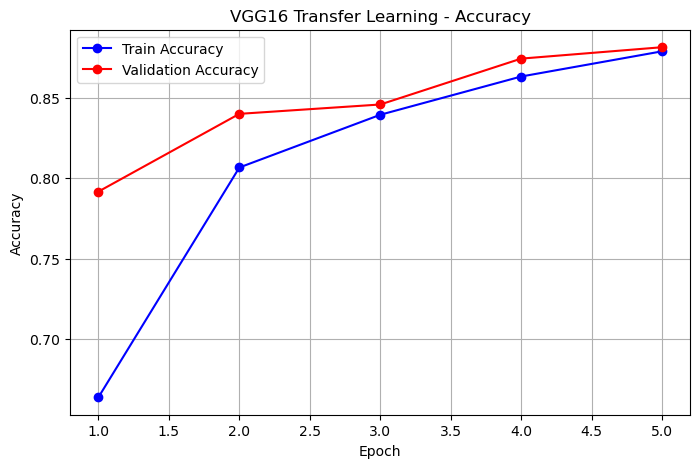

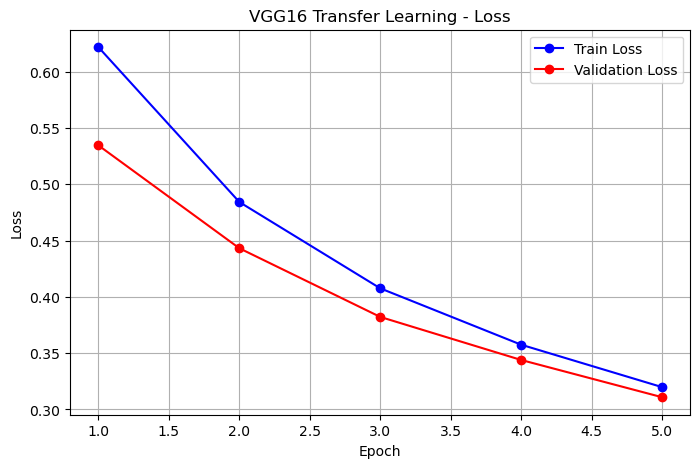

In [26]:
plotLearningCurve(history_tl, title="VGG16 Transfer Learning")